# Clustering Techniques & Models

In [132]:
## Importing cleaned dataset for modeling
import pickle as pk
df_cleaned = ''
with open(r"df_cleaned.pkl", 'rb') as file:
    df_cleaned = pk.load(file)

In [133]:
## Importing X_test for modeling
import pickle as pk
X_test = ''
with open(r"X_test.pkl", 'rb') as file:
    X_test = pk.load(file)

In [134]:
## Importing X_train for modeling
import pickle as pk
X_train = ''
with open(r"X_train.pkl", 'rb') as file:
    X_train = pk.load(file)

In [135]:
## Importing y_test for modeling
import pickle as pk
y_test = ''
with open(r"y_test.pkl", 'rb') as file:
    y_test = pk.load(file)

In [136]:
## Importing y_train for modeling
import pickle as pk
y_train = ''
with open(r"y_train.pkl", 'rb') as file:
    y_train = pk.load(file)

In [137]:
## Importing StandardScaler from SciKit Learn
from sklearn.preprocessing import StandardScaler

## Creating a function standard scaler that will scale the the dataframe
scaler_X = StandardScaler()

import pandas as pd
## Scaling the data
X_train = pd.DataFrame(scaler_X.fit_transform(X_train), columns = X_train.columns)
X_test = pd.DataFrame(scaler_X.transform(X_test), columns = X_test.columns)

# Building and Testing the Models

In [138]:
## Using KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from sklearn.model_selection import GridSearchCV
import numpy as np

knn = KNeighborsClassifier()

param_grid = {'n_neighbors': np.arange(5, 30, 2), # Check odd numbers 5... to 29
              'weights': ['uniform', 'distance']}

In [139]:
from sklearn.model_selection import KFold
cv_5 = KFold(n_splits=5, shuffle=True, random_state=1234)

## Run the Search
gs = GridSearchCV(knn, 
                    param_grid, 
                    cv=cv_5, ## Cross Validate!
                    scoring = 'recall' ## recall most important because we are trying to find Churners
                    ).fit(X_train, y_train)
gs.best_estimator_

,n_neighbors,np.int64(5)
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [140]:
## Seeing score of best_estimator or search
knn_best_gs = gs.best_estimator_

y_train_hat = knn_best_gs.predict(X_train)
y_test_hat = knn_best_gs.predict(X_test)

knn_best_gs.score(X_train,y_train), knn_best_gs.score(X_test, y_test)

(1.0, 0.9590747330960854)

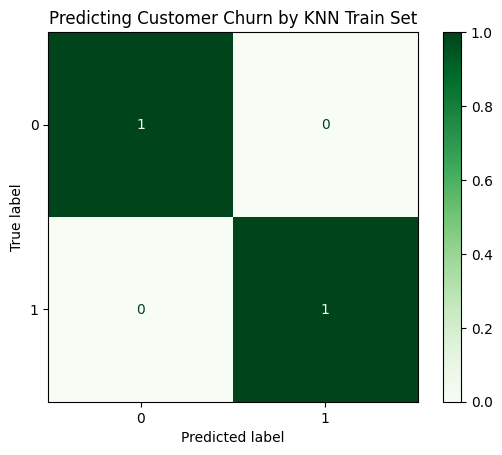

In [141]:
## Creating confusion matrix for train set
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
cm_train = confusion_matrix(y_train, y_train_hat, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp.plot(cmap = 'Greens')

plt.title("Predicting Customer Churn by KNN Train Set")
plt.grid(False)
plt.show()

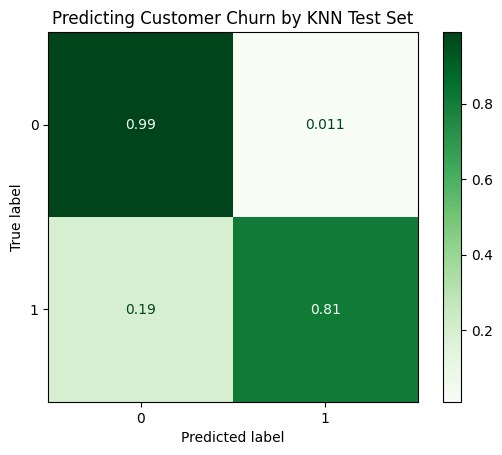

In [142]:
## Creating confusion matrix for test set
cm_test = confusion_matrix(y_test, y_test_hat, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot(cmap = 'Greens')
plt.title("Predicting Customer Churn by KNN Test Set")
plt.grid(False)
plt.show()

In [143]:
from sklearn.model_selection import cross_validate

# Convert to numpy arrays for pyagrum compatibility
X_train_np = X_train.to_numpy()
y_train_np = y_train.astype(int).to_numpy().ravel()

# Get cross-validation scores
cv_results = cross_validate(
    knn_best_gs,
    X_train_np,
    y_train_np,
    cv=10,
    scoring=['balanced_accuracy', 'precision', 'recall', 'f1'],
    n_jobs= 1,
    verbose=0
)

# Extract and organize results
metrics = {
    'Balanced Accuracy': cv_results['test_balanced_accuracy'],
    'Precision': cv_results['test_precision'],
    'Recall': cv_results['test_recall'],
    'F1 Score': cv_results['test_f1']
}

# Print detailed results
print(f"{'Metric':<20} {'Mean':<12} {'Std Dev':<12}")

for metric_name, values in metrics.items():
    mean_val = values.mean()
    std_val = values.std()
    print(f"{metric_name:<20} {mean_val:<12.4f} {std_val:<12.4f}")

Metric               Mean         Std Dev     
Balanced Accuracy    0.8783       0.0269      
Precision            0.9292       0.0306      
Recall               0.7686       0.0545      
F1 Score             0.8400       0.0341      


In [144]:
## Grabbing permutation importance
from sklearn.inspection import permutation_importance


perm_import = permutation_importance(knn_best_gs,## The Model we are evaluating (tuned!)
                                     X_train,         
                                     y_train,
                                     n_repeats=5,## The Number of shuffles (permutations) to do FOR EACH variable
                                     random_state=1234,
                                     n_jobs = 2) ## In parallel
perm_import 

{'importances_mean': array([0.02101046, 0.03035834, 0.02216782, 0.0126864 , 0.01451146,
        0.02555086, 0.02755397, 0.04887603, 0.02394836, 0.00819052,
        0.00832406, 0.01451146, 0.00627643, 0.0312041 , 0.02345871,
        0.01709326, 0.0198531 , 0.02777654, 0.00378366, 0.01629201,
        0.01446695, 0.00445137, 0.00961496, 0.02550634]),
 'importances_std': array([0.00130994, 0.00157757, 0.0016452 , 0.00132797, 0.00220062,
        0.00121417, 0.00192184, 0.00170436, 0.00197873, 0.00141747,
        0.00177274, 0.00105714, 0.00078878, 0.0019927 , 0.00077867,
        0.00098937, 0.00203209, 0.00124638, 0.00028153, 0.00210395,
        0.00092306, 0.00062952, 0.00094847, 0.00075279]),
 'importances': array([[0.02158914, 0.02092143, 0.02270198, 0.021144  , 0.01869575],
        [0.02871133, 0.03227242, 0.02826619, 0.03115958, 0.03138215],
        [0.02136657, 0.02381482, 0.02359225, 0.01936345, 0.02270198],
        [0.01290897, 0.01224126, 0.01179613, 0.01513465, 0.01135099],
      

In [145]:
perm_import_df = pd.DataFrame(perm_import['importances'].transpose(),  
                                 columns = knn_best_gs.feature_names_in_)
perm_import_df

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_Electronic Payment,Gender_Male,PreferredOrderCat_Grocery,PreferredOrderCat_Laptop & Accessory,PreferredOrderCat_Mobile Phone,PreferredOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,0.021589,0.028711,0.021367,0.012909,0.012019,0.025150,0.030492,0.051191,0.024928,0.007345,...,0.023370,0.015580,0.022034,0.026263,0.003784,0.014467,0.014690,0.003784,0.011351,0.026041
1,0.020921,0.032272,0.023815,0.012241,0.018473,0.025595,0.027153,0.046739,0.022702,0.007122,...,0.024928,0.016693,0.020254,0.027376,0.003784,0.017360,0.015357,0.004674,0.008680,0.024928
2,0.022702,0.028266,0.023592,0.011796,0.014022,0.025595,0.024483,0.050523,0.024483,0.006677,...,0.022925,0.016915,0.021812,0.027821,0.004229,0.018251,0.015357,0.004006,0.009348,0.025150
3,0.021144,0.031160,0.019363,0.015135,0.014912,0.027598,0.028044,0.047630,0.020921,0.009793,...,0.023370,0.017805,0.016693,0.027376,0.003339,0.013132,0.012909,0.004229,0.008903,0.026708
4,0.018696,0.031382,0.022702,0.011351,0.013132,0.023815,0.027598,0.048297,0.026708,0.010016,...,0.022702,0.018473,0.018473,0.030047,0.003784,0.018251,0.014022,0.005564,0.009793,0.024705


In [146]:
## Melt as before to Tidy Data
perm_import_df_mlt = perm_import_df.melt(value_vars=knn_best_gs.feature_names_in_, 
                                         var_name='Variable', 
                                         value_name='Importance').sort_values(by = 'Importance', ascending= False)
perm_import_df_mlt

,Variable,Importance
35,Complain,0.051191
37,Complain,0.050523
39,Complain,0.048297
38,Complain,0.047630
36,Complain,0.046739
...,...,...
90,PreferredOrderCat_Grocery,0.003784
94,PreferredOrderCat_Grocery,0.003784
91,PreferredOrderCat_Grocery,0.003784
105,PreferredOrderCat_Others,0.003784


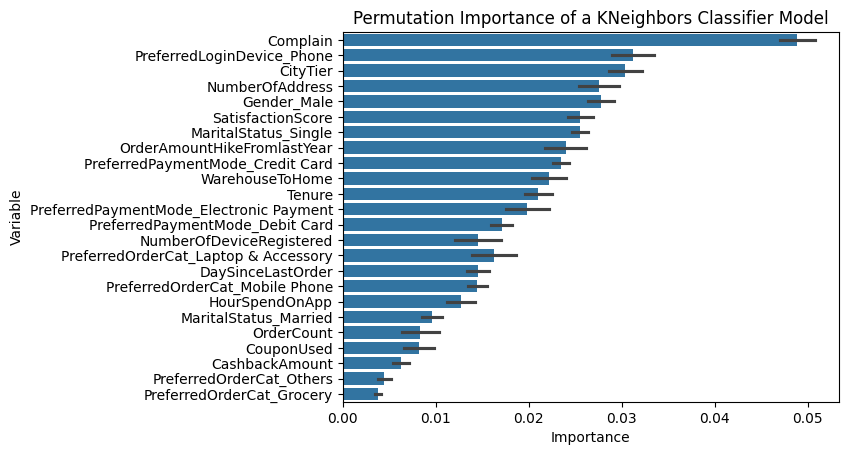

In [147]:
import seaborn as sns
sns.barplot(data = perm_import_df_mlt,
            y = 'Variable',
            x = 'Importance', 
            errorbar = 'sd')
plt.title("Permutation Importance of a KNeighbors Classifier Model");

In [148]:
## Testing and Using KMeans 
from sklearn.cluster import KMeans


kmns = KMeans(n_clusters = 4, 
              max_iter = 300, ## Number of times we update each observation's cluster,
              init = 'k-means++', ## using k-means++ so beginning clusters aren't random
              n_init= 'auto', ## Number of times we re-start initialization. # Since using 'k-means++' n_init will be 1
              random_state = 1234)

## Here, we do not hand y to the model
kmns = kmns.fit(X_train)
y_train_hat = kmns.predict(X_train)
y_test_hat = kmns.predict(X_test)

## The total, negative inertia of the given X sets
kmns.score(X_train), kmns.score(X_test)

(-86959.0621178271, -21171.251495459557)

In [149]:
## Sum of squared distances of samples to their closest cluster center 
kmns.inertia_

86959.0621178271

  0%|          | 0/49 [00:00<?, ?it/s]

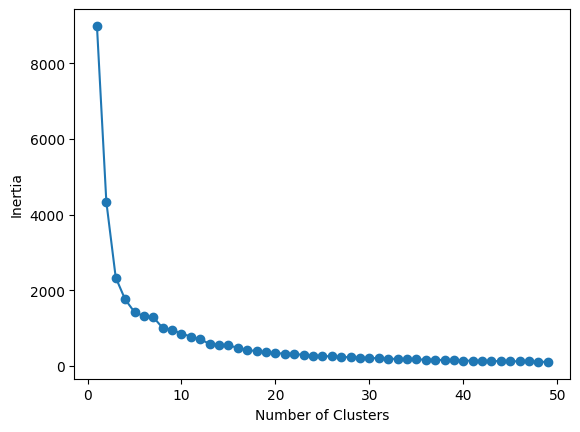

In [150]:
import numpy as np
from tqdm.notebook import tqdm
# Calculate Inertia for a range of number of cluster
# 'Elbow Method'
inertias = []
possible_ks = np.arange(1, 50, 1, dtype=int) ## np.arange is (start, stop, increment)

X = X_train[['DaySinceLastOrder', 'OrderCount']]

for i in tqdm(possible_ks):
    km = KMeans(n_clusters=i,   ## Number of Clusters
                max_iter=300,   ## Number of times we update each observation's cluster, Default is 300
                init='k-means++',  ## How do we intialize the clusters?
                n_init='auto',       ## Number of times to restart and choose random starting centroids
                random_state=1234)
    km.fit(X)
    inertias.append(km.inertia_)

# plot
plt.plot(possible_ks, inertias, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

From the Elbow Method I will choose 4 clusters as it is near the outer-most point of the curve and where the graph starts to plateau, indicating more clusters would not have much of a impact.

In [151]:
from sklearn.metrics import accuracy_score

accuracy_score(y_train, y_train_hat), accuracy_score(y_test, y_test_hat)

(0.22123302915646562, 0.1806049822064057)

# Analysis

### Model Performance

####  KNeighborsClassifier

Accuracy: 0.9591

Class = 0 (Non-Churn)
- Recall = 0.99
- The model almost never misses customers who stay.


Class = 1 (Churn)
- Recall = 0.7686
- The model correctly identifies most churners.

### Interpretation

Overall Model Performance
- The KNeighborsClassifier performs exceptionally well, reaching approximately 96% accuracy.
- It correctly classifies non-churn customers almost perfectly (99%).
- Most importantly, its ability to identify churners jumped from ~30% to ~77%, meaning it now captures the vast majority of customers who actually leave.
- Train Accuracy = 100%, Test Accuracy = ~96%: The perfect training score is expected when using weights='distance' (as points predict themselves), but the high Test Accuracy confirms the model is generalizing well and not just memorizing noise.
- This makes the model highly actionable for business decisions, as it catches almost 8 out of 10 leaving customers while maintaining high precision.

### Permutation Importance

Top Predictors of Churn:
- Complain is the strongest predictor. Obviously, confirming the intuitive belief that customers who file complaints behave very differently from those who do not (likely much higher churn risk).
- PreferredLoginDevice_Phone and CityTier are next, suggesting that how and where customers access the service strongly influences churn behavior.
- NumberOfAddress and Gender_Male also rank high, meaning account complexity and certain demographic patterns play a noticeable role.
- SatisfactionScore and MaritalStatus_Single confirm that personal experience and life stage are meaningful churn-related signals.

Overall Interpretation:
- The permutation importance results show that most of the available features contribute to the predictive power of the model, indicating that customer churn in this dataset is influenced by a wide range of behavioral, demographic, and engagement-related factors. Rather than relying on a single dominant predictor, the KNN model leverages the combined effect of many variables to distinguish between churned and retained customers.

### Kmeans algorithm not very good at predicting churn. Decided to focus on classifier.

In [152]:
import pickle

# Save the model
with open("7_Clustering.pkl", "wb") as file:
    pickle.dump('7_Clustering', file)